<a href="https://colab.research.google.com/github/jhamidi1/Data-205-Capstone-Project/blob/main/DATA%20205%20Capstone%20Project%20Code/03_DATA205_Final_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 205 Capstone Project

Educational Attainment and Socioeconomic Inequality Across Pittsburgh Neighborhoods

**Final Statistical Analysis Notebook**

## Section 1: Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section 2: Load Final Cleaned Dataset

In [20]:
final_data = pd.read_csv('/content/04_Final_Merged_Pittsburgh_Neighborhood_Data.csv')
final_data.head()

,Neighborhood,Adult_Population_25_Over,Total_Bachelors_Degree,Bachelors_Degree_Pct,Total_Households,Households_With_Wage_Income,Wage_Income_Pct,Population_Below_Poverty,Poverty_Rate
0,Allegheny Center,791.0,176.0,22.25,733.0,462.0,63.03,516.0,45.66
1,Allegheny West,283.0,121.0,42.76,150.0,120.0,80.00,45.0,13.60
2,Allentown,1611.0,72.0,4.47,1138.0,772.0,67.84,750.0,28.58
3,Arlington,1271.0,84.0,6.61,685.0,566.0,82.63,343.0,18.15
4,Arlington Heights,182.0,0.0,0.00,170.0,96.0,56.47,278.0,73.16


## Section 3: Descriptive Statistics Overview

In [21]:
final_data.describe()

,Adult_Population_25_Over,Total_Bachelors_Degree,Bachelors_Degree_Pct,Total_Households,Households_With_Wage_Income,Wage_Income_Pct,Population_Below_Poverty,Poverty_Rate
count,91.000000,91.000000,90.000000,91.000000,91.000000,90.000000,91.000000,90.000000
mean,2248.296703,428.417582,16.028778,1469.560440,1066.351648,71.504889,721.164835,25.153667
std,2209.771439,575.754598,10.243049,1450.270007,1118.824377,11.954243,659.230549,16.032556
min,0.000000,0.000000,0.000000,0.000000,0.000000,33.070000,0.000000,0.000000
25%,773.000000,60.500000,6.580000,472.500000,337.000000,63.607500,214.000000,14.027500
50%,1527.000000,218.000000,16.060000,1138.000000,764.000000,73.430000,558.000000,21.625000
75%,2900.500000,513.000000,23.447500,1857.500000,1287.000000,78.725000,1121.500000,32.892500
max,11164.000000,3116.000000,43.040000,7462.000000,6032.000000,100.000000,3505.000000,80.870000


In [22]:
print("Rows and columns:", final_data.shape)
final_data.columns

Rows and columns: (91, 9)


Index(['Neighborhood', 'Adult_Population_25_Over', 'Total_Bachelors_Degree',
       'Bachelors_Degree_Pct', 'Total_Households',
       'Households_With_Wage_Income', 'Wage_Income_Pct',
       'Population_Below_Poverty', 'Poverty_Rate'],
      dtype='object')

In [23]:
final_data.isnull().sum()

,0
Neighborhood,0
Adult_Population_25_Over,0
Total_Bachelors_Degree,0
Bachelors_Degree_Pct,1
Total_Households,0
Households_With_Wage_Income,0
Wage_Income_Pct,1
Population_Below_Poverty,0
Poverty_Rate,1


In [24]:
final_data["Bachelors_Degree_Pct"] = final_data["Bachelors_Degree_Pct"].fillna(0)
final_data["Wage_Income_Pct"] = final_data["Wage_Income_Pct"].fillna(0)
final_data["Poverty_Rate"] = final_data["Poverty_Rate"].fillna(0)

## EDA Metric 01: Top 5 Neighborhoods with Highest Bachelor's Degree Attainment
This visualization identifies the Pittsburgh neighborhoods with the strongest concentration of residents holding a bachelor's degree, highlighting communities with the highest levels of educational attainment.

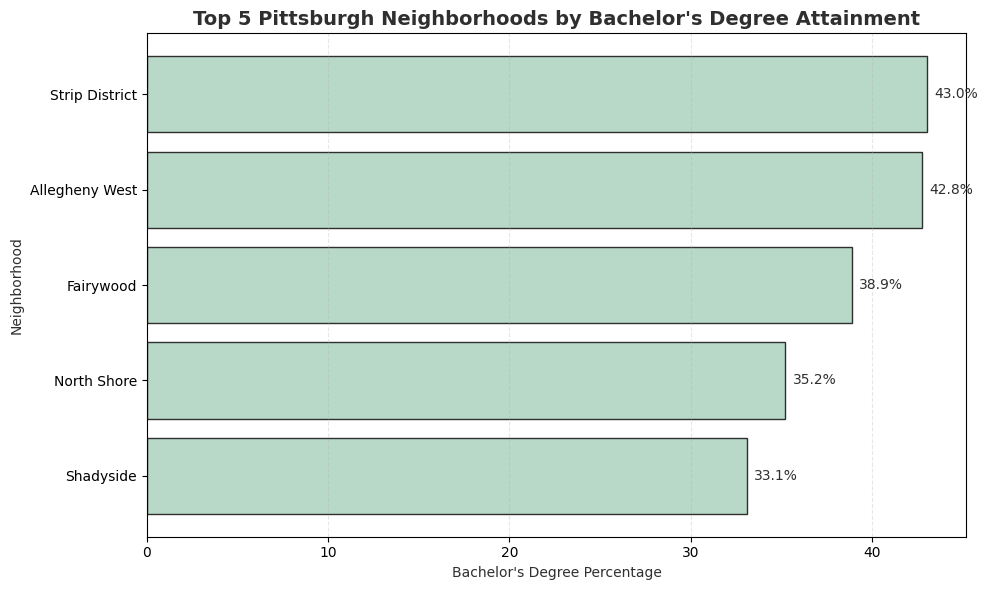

In [25]:
sage = "#B8D8C8"
dark = "#2F2F2F"

top_edu = final_data.sort_values("Bachelors_Degree_Pct", ascending=False).head(5)

plt.figure(figsize=(10,6), facecolor="white")
plt.barh(top_edu["Neighborhood"], top_edu["Bachelors_Degree_Pct"], color=sage, edgecolor=dark)
plt.xlabel("Bachelor's Degree Percentage", color=dark)
plt.ylabel("Neighborhood", color=dark)
plt.title("Top 5 Pittsburgh Neighborhoods by Bachelor's Degree Attainment", fontsize=14, weight="bold", color=dark)
plt.gca().invert_yaxis()

for i, value in enumerate(top_edu["Bachelors_Degree_Pct"]):
    plt.text(value + 0.4, i, f"{value:.1f}%", color=dark, va='center')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## EDA Metric 02: Top 5 Neighborhoods with Highest Household Wage Income Participation
This visualization highlights the neighborhoods with the greatest percentage of households reporting wage or salary income, providing insight into areas with stronger workforce economic participation.

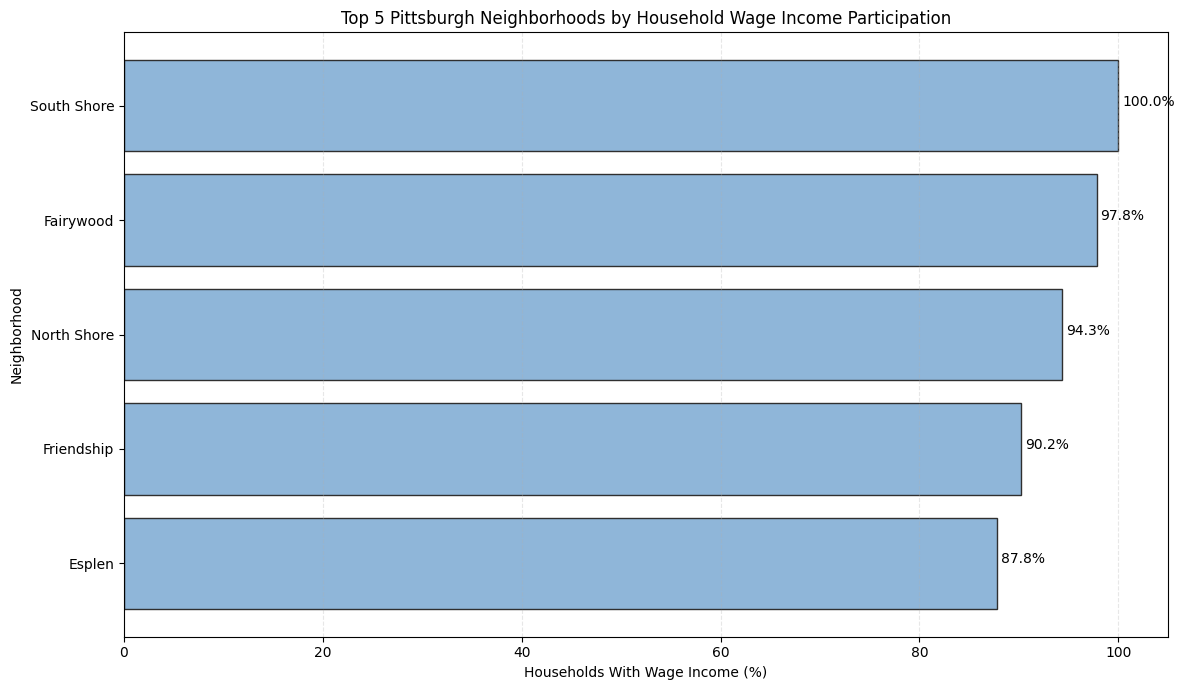

In [26]:
blue = "#8FB6D9"
dark = "#2F2F2F"

top_income = final_data.sort_values("Wage_Income_Pct", ascending=False).head(5)

plt.figure(figsize=(12,7))
plt.barh(top_income["Neighborhood"], top_income["Wage_Income_Pct"], color=blue, edgecolor=dark)
plt.xlabel("Households With Wage Income (%)")
plt.ylabel("Neighborhood")
plt.title("Top 5 Pittsburgh Neighborhoods by Household Wage Income Participation")
plt.gca().invert_yaxis()

for i, value in enumerate(top_income["Wage_Income_Pct"]):
    plt.text(value + 0.4, i, f"{value:.1f}%")

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## EDA Metric 03: Top 5 Neighborhoods with Highest Poverty Concentration
This visualization identifies the neighborhoods with the largest proportion of residents living below the poverty threshold, emphasizing areas where socioeconomic hardship is most concentrated.

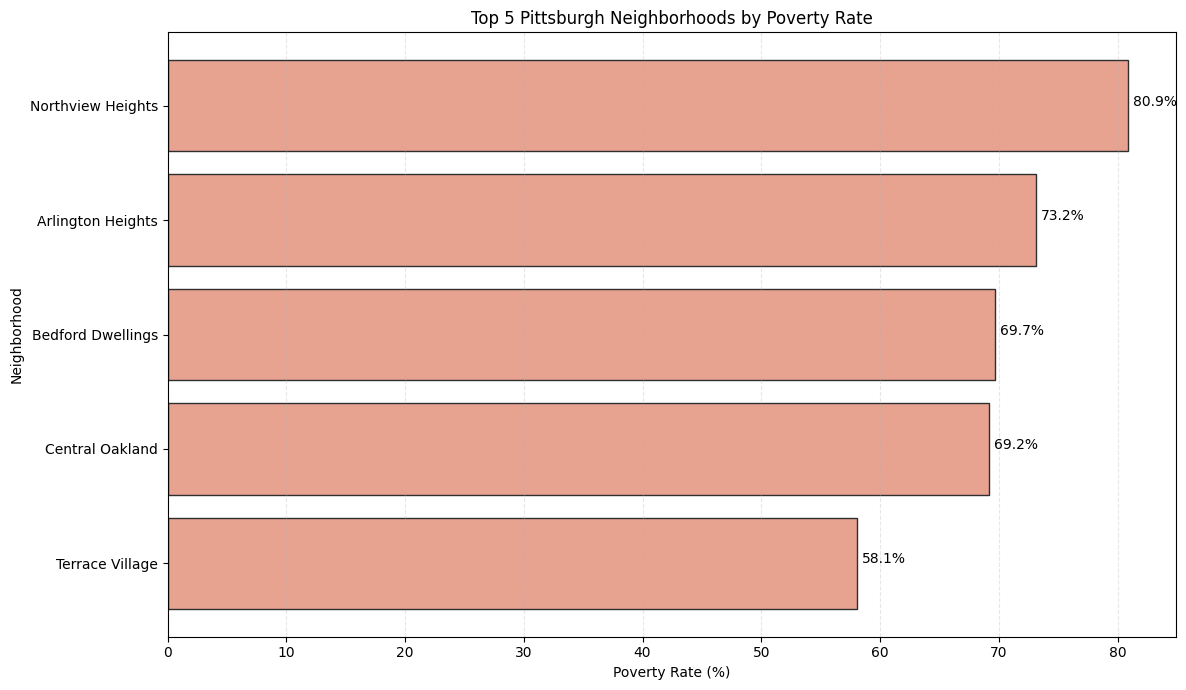

In [27]:
coral = "#E7A38F"
dark = "#2F2F2F"

top_poverty = final_data.sort_values("Poverty_Rate", ascending=False).head(5)

plt.figure(figsize=(12,7))
plt.barh(top_poverty["Neighborhood"], top_poverty["Poverty_Rate"], color=coral, edgecolor=dark)
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Neighborhood")
plt.title("Top 5 Pittsburgh Neighborhoods by Poverty Rate")
plt.gca().invert_yaxis()

for i, value in enumerate(top_poverty["Poverty_Rate"]):
    plt.text(value + 0.4, i, f"{value:.1f}%")

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## EDA METRIC 04 — Relationship Between Bachelor's Degree Attainment and Wage Income Participation

This scatterplot will show whether the neighborhoods with more educated residents tend to have higher wage income percentages.

In [28]:
scatter_data = final_data[final_data["Bachelors_Degree_Pct"] > 0]

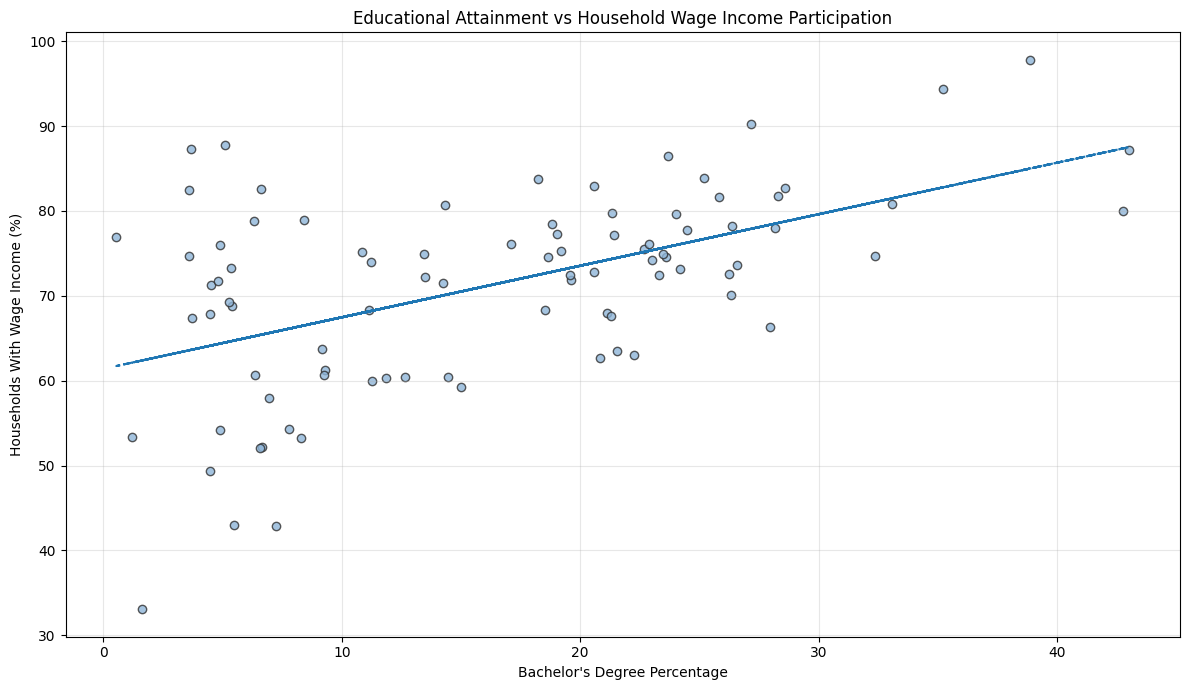

In [29]:
plt.figure(figsize=(12,7))
plt.scatter(scatter_data["Bachelors_Degree_Pct"], scatter_data["Wage_Income_Pct"],
            color=blue, edgecolor=dark, alpha=0.8)

plt.xlabel("Bachelor's Degree Percentage")
plt.ylabel("Households With Wage Income (%)")
plt.title("Educational Attainment vs Household Wage Income Participation")

z = np.polyfit(scatter_data["Bachelors_Degree_Pct"], scatter_data["Wage_Income_Pct"], 1)
p = np.poly1d(z)
plt.plot(scatter_data["Bachelors_Degree_Pct"], p(scatter_data["Bachelors_Degree_Pct"]), linestyle="--")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA METRIC 05 — Educational Attainment vs Poverty Rate



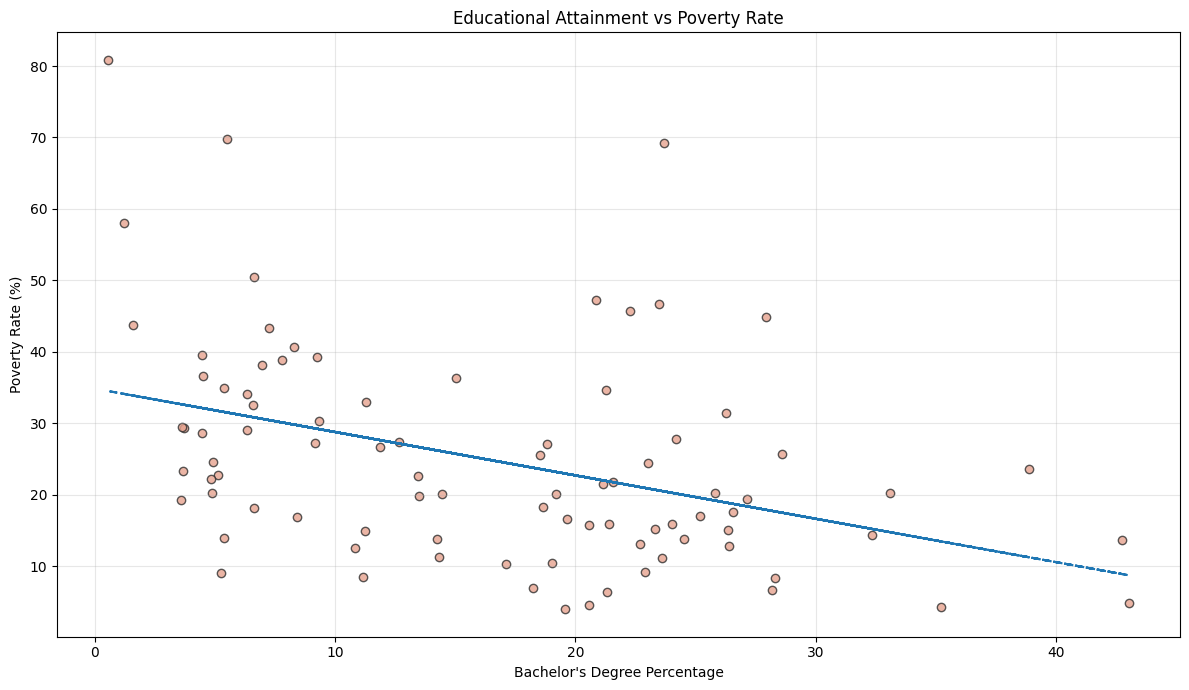

In [30]:
plt.figure(figsize=(12,7))
plt.scatter(scatter_data["Bachelors_Degree_Pct"], scatter_data["Poverty_Rate"],
            color=coral, edgecolor=dark, alpha=0.8)

plt.xlabel("Bachelor's Degree Percentage")
plt.ylabel("Poverty Rate (%)")
plt.title("Educational Attainment vs Poverty Rate")

z = np.polyfit(scatter_data["Bachelors_Degree_Pct"], scatter_data["Poverty_Rate"], 1)
p = np.poly1d(z)
plt.plot(scatter_data["Bachelors_Degree_Pct"], p(scatter_data["Bachelors_Degree_Pct"]), linestyle="--")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA METRIC 06 — Representative Neighborhood Comparison Dashboard

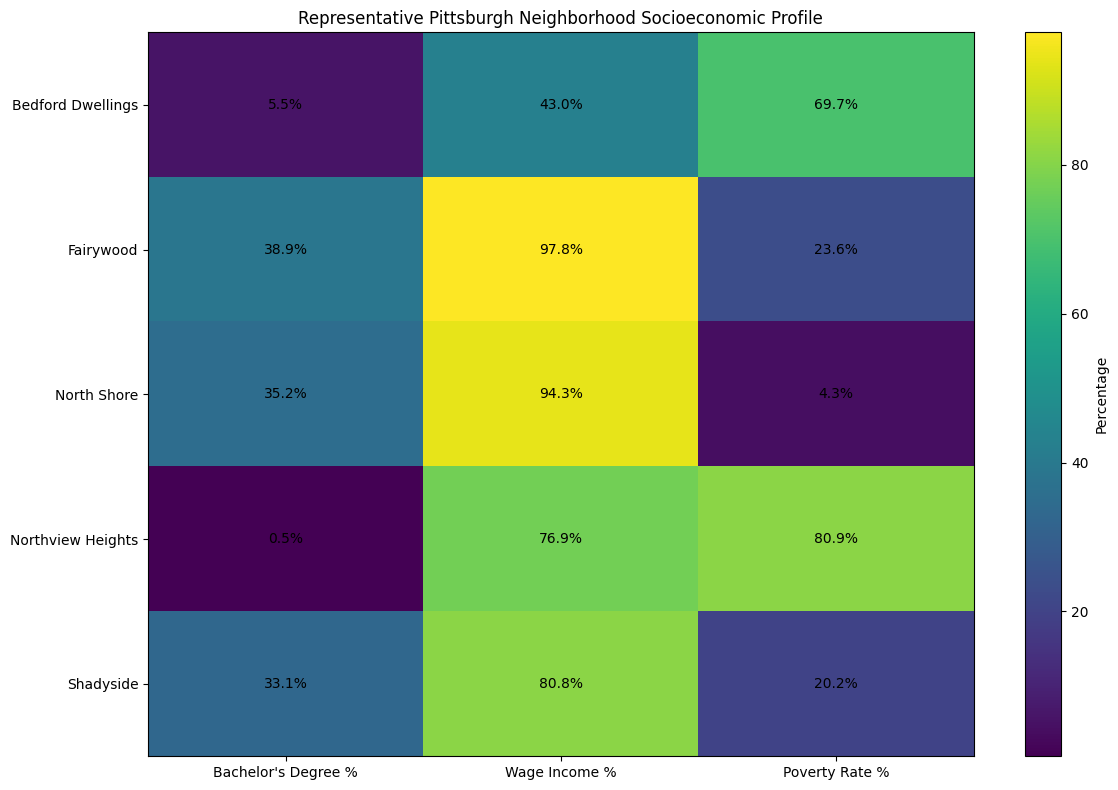

In [31]:
selected = final_data[final_data["Neighborhood"].isin([
    "Fairywood",
    "North Shore",
    "Shadyside",
    "Northview Heights",
    "Bedford Dwellings"
])].copy()

selected = selected.set_index("Neighborhood")[[
    "Bachelors_Degree_Pct",
    "Wage_Income_Pct",
    "Poverty_Rate"
]]

selected = selected.rename(columns={
    "Bachelors_Degree_Pct": "Bachelor's Degree %",
    "Wage_Income_Pct": "Wage Income %",
    "Poverty_Rate": "Poverty Rate %"
})

plt.figure(figsize=(12,8))
plt.imshow(selected, aspect="auto")

plt.xticks(range(len(selected.columns)), selected.columns)
plt.yticks(range(len(selected.index)), selected.index)

for i in range(len(selected.index)):
    for j in range(len(selected.columns)):
        plt.text(j, i, f"{selected.iloc[i, j]:.1f}%", ha="center", va="center", color="black")

plt.colorbar(label="Percentage")
plt.title("Representative Pittsburgh Neighborhood Socioeconomic Profile")
plt.tight_layout()
plt.show()

## Section 4: Statistical Analysis

In [32]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import f_oneway

**Simple Linear Regression**

In [33]:
model1 = smf.ols(
    'Poverty_Rate ~ Bachelors_Degree_Pct',
    data=final_data
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:           Poverty_Rate   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     12.80
Date:                Wed, 13 May 2026   Prob (F-statistic):           0.000563
Time:                        17:26:52   Log-Likelihood:                -375.72
No. Observations:                  91   AIC:                             755.4
Df Residuals:                      89   BIC:                             760.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               33.6765 

**Second Regression**

In [34]:
model2 = smf.ols(
    'Wage_Income_Pct ~ Bachelors_Degree_Pct',
    data=final_data
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        Wage_Income_Pct   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     26.59
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.51e-06
Time:                        17:26:52   Log-Likelihood:                -357.23
No. Observations:                  91   AIC:                             718.5
Df Residuals:                      89   BIC:                             723.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.3690 

**Multiple Regression**

In [35]:
model3 = smf.ols(
    'Poverty_Rate ~ Bachelors_Degree_Pct + Wage_Income_Pct',
    data=final_data
).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:           Poverty_Rate   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     9.026
Date:                Wed, 13 May 2026   Prob (F-statistic):           0.000272
Time:                        17:26:52   Log-Likelihood:                -373.34
No. Observations:                  91   AIC:                             752.7
Df Residuals:                      88   BIC:                             760.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               50.3604 

**ANOVA**

In [36]:
final_data['Education_Group'] = pd.qcut(
    final_data['Bachelors_Degree_Pct'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [37]:
low = final_data[final_data['Education_Group'] == 'Low']['Poverty_Rate']
medium = final_data[final_data['Education_Group'] == 'Medium']['Poverty_Rate']
high = final_data[final_data['Education_Group'] == 'High']['Poverty_Rate']

anova_result = f_oneway(low, medium, high)

print(anova_result)

F_onewayResult(statistic=np.float64(6.598709067857312), pvalue=np.float64(0.0021368918751240354))
